In [2]:
# ── Import ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ── Preprocessing ───────────────────────────────────────────────
df = pd.read_excel('kuesionardivisipramuka smaba.xlsx')
df.columns = df.columns.str.strip()

for col in ['Nama Lengkap', 'Kelas']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

TARGET = 'Divisi yang paling di minati?'
df = df.fillna(df.mode().iloc[0])

encoders = {}
df_encoded = df.copy()
for col in df.columns:
    is_text = df[col].dtype == 'object' or str(df[col].dtype) == 'string'
    if not is_text:
        is_text = df[col].apply(lambda x: isinstance(x, str)).any()
    if is_text:
        df_encoded[col] = df_encoded[col].astype(str).str.strip()
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        encoders[col] = le

feature_cols = [col for col in df_encoded.columns if col != TARGET]
X = df_encoded[feature_cols].values
y = df_encoded[TARGET].values
label_names = list(encoders[TARGET].classes_)

sm = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = sm.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print("Preprocessing selesai!")

Preprocessing selesai!


In [4]:
# ── Model ───────────────────────────────────────────────────────
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
print("Training selesai!")

Training selesai!


In [5]:
# ── Evaluasi ────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_res, y_res, cv=cv, scoring='accuracy')

print(f"Train Accuracy : {accuracy_score(y_train, model.predict(X_train)):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test,  model.predict(X_test)):.4f}")
print(f"CV Mean        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test), target_names=label_names, zero_division=0))

Train Accuracy : 1.0000
Test  Accuracy : 0.7273
CV Mean        : 0.8000 ± 0.0170

Classification Report:
                          precision    recall  f1-score   support

Bimbingan & Pengembangan       0.67      0.73      0.70        11
          Kajian Pramuka       0.89      0.73      0.80        11
                Kegiatan       0.86      0.55      0.67        11
   Penelitian & Evaluasi       0.62      0.91      0.74        11

                accuracy                           0.73        44
               macro avg       0.76      0.73      0.73        44
            weighted avg       0.76      0.73      0.73        44



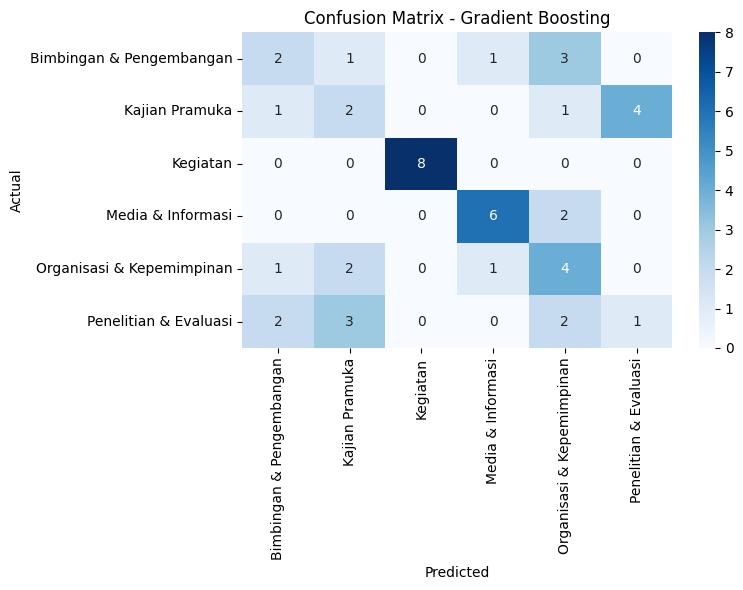

In [5]:
# ── Confusion Matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

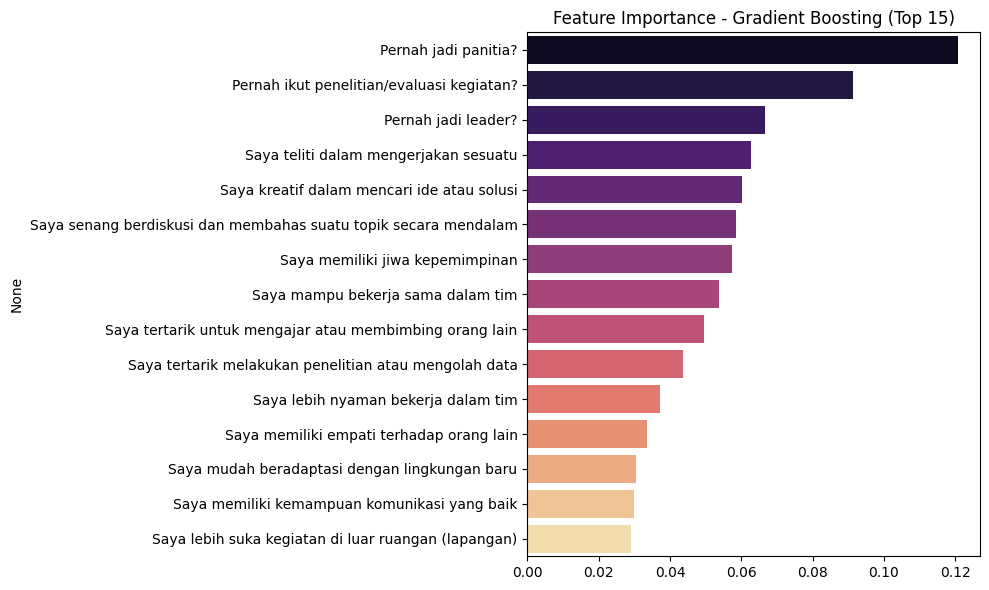

In [6]:
# ── Feature Importance ──────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='magma')
plt.title('Feature Importance - Gradient Boosting (Top 15)')
plt.tight_layout()
plt.show()